In [1]:
import socket
print(socket.gethostname())

ws-l6-013


In [2]:
import torch
import torchvision
from torch.optim import SGD
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.cuda.amp import autocast, GradScaler
import torchvision.transforms as transforms
import math
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt
import numpy as np
import torch.optim as optim
from tqdm import tqdm

In [3]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

batch_size = 256

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

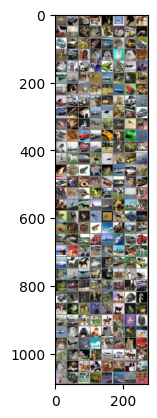

ship  car   frog  horse deer  plane cat   horse horse ship  frog  frog  cat   cat   truck bird  car   car   frog  frog  ship  cat   truck car   cat   truck dog   cat   dog   dog   dog   dog   ship  truck truck car   frog  bird  plane car   ship  ship  dog   bird  ship  deer  bird  car   ship  cat   deer  horse deer  ship  frog  frog  truck truck plane horse deer  frog  car   plane car   deer  cat   ship  bird  frog  truck car   frog  frog  cat   plane deer  deer  plane dog   cat   frog  car   truck frog  dog   frog  bird  bird  ship  car   ship  deer  frog  frog  frog  bird  horse plane bird  plane bird  car   plane frog  cat   frog  cat   frog  ship  ship  cat   car   bird  cat   frog  car   ship  dog   truck dog   horse bird  frog  truck horse ship  cat   dog   bird  dog   plane ship  cat   horse dog   dog   dog   frog  plane deer  deer  truck ship  plane bird  frog  frog  plane car   truck car   truck ship  plane truck ship  ship  truck truck bird  deer  bird  deer  dog   plane cat 

In [4]:

# functions to show an image


def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [6]:



class VGG16(nn.Module):
    def __init__(self, n_classes=10):
        super(VGG16, self).__init__()
        self.features = nn.Sequential(
            # Conv Layer Block 1
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Conv Layer Block 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Conv Layer Block 3
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Conv Layer Block 4
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Conv Layer Block 5
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        self.classifier = nn.Sequential(
            nn.Linear(512, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(4096, n_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

net = VGG16()
net.to(device)

VGG16(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation

In [ ]:

# Define a loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

# Training loop
for epoch in range(10):  # loop over the dataset multiple times

    running_loss = 0.0
    for i, data in tqdm(enumerate(trainloader, 0)):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)


        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if i % 2000 == 1999:    # print every 2000 mini-batches
            print(f'[Epoch {epoch + 1}, Batch {i + 1}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0

print('Finished Training')

196it [00:07, 26.55it/s]
196it [00:07, 26.64it/s]
196it [00:07, 26.69it/s]
196it [00:07, 26.85it/s]
196it [00:07, 26.58it/s]
196it [00:07, 26.30it/s]
196it [00:07, 26.75it/s]
196it [00:07, 26.53it/s]
196it [00:07, 26.67it/s]
196it [00:07, 26.72it/s]

Finished Training


In [8]:
# Switch the model to evaluation mode
net.eval()

all_labels = []
all_preds = []
# Disable gradient calculation for testing
with torch.no_grad():
    for data in testloader:
        images, labels = data
        images, labels = images.to(device), labels.to(device)
        outputs = net(images)
        _, predicted = torch.max(outputs, 1)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())

# Calculate accuracy and F1 score
accuracy = accuracy_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds, average='weighted')

print(f'Accuracy: {accuracy:.4f}')
print(f'F1 Score: {f1:.4f}')

Accuracy: 0.1000
F1 Score: 0.0182


### Extensive Task

#### resnet

In [9]:
class BasicBlock(nn.Module):
    expansion = 1
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride, 1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, 1, 1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)
        self.short = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.short = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride, bias=False),
                nn.BatchNorm2d(out_ch),
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)), inplace=True)
        out = self.bn2(self.conv2(out))
        out += self.short(x)
        return F.relu(out, inplace=True)

def _make_layer(block, in_ch, out_ch, num_blocks, stride):
    strides = [stride] + [1]*(num_blocks-1)
    layers, ch = [], in_ch
    for s in strides:
        layers.append(block(ch, out_ch, s))
        ch = out_ch * block.expansion
    return nn.Sequential(*layers), ch

class ResNet18(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, 3, 1, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )
        c = 64
        self.layer1, c = _make_layer(BasicBlock, c, 64,  2, stride=1)
        self.layer2, c = _make_layer(BasicBlock, c, 128, 2, stride=2)
        self.layer3, c = _make_layer(BasicBlock, c, 256, 2, stride=2)
        self.layer4, c = _make_layer(BasicBlock, c, 512, 2, stride=2)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc   = nn.Linear(c, num_classes)

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1.0); nn.init.constant_(m.bias, 0.0)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x); x = self.layer2(x); x = self.layer3(x); x = self.layer4(x)
        x = self.pool(x).flatten(1)
        return self.fc(x)

# # 快速前向检查
# with torch.no_grad():
#     net = ResNet18().to(device)
#     x = torch.randn(2,3,32,32, device=device)
#     y = net(x)
#     print("ResNet18 output shape:", y.shape)


#### dense-net

In [10]:
class _BNReLUConv(nn.Sequential):
    def __init__(self, in_ch, out_ch, k=3, s=1, p=1):
        super().__init__(
            nn.BatchNorm2d(in_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_ch, out_ch, k, s, p, bias=False),
        )

class DenseLayer(nn.Module):
    def __init__(self, in_ch, growth_rate, bottleneck=True):
        super().__init__()
        inter = 4 * growth_rate if bottleneck else growth_rate
        self.bottleneck = bottleneck
        if bottleneck:
            self.bn_relu_conv1 = _BNReLUConv(in_ch, inter, k=1, s=1, p=0)
            self.bn_relu_conv2 = _BNReLUConv(inter, growth_rate, k=3, s=1, p=1)
        else:
            self.bn_relu_conv2 = _BNReLUConv(in_ch, growth_rate, k=3, s=1, p=1)

    def forward(self, x):
        if self.bottleneck:
            out = self.bn_relu_conv1(x)
            out = self.bn_relu_conv2(out)
        else:
            out = self.bn_relu_conv2(x)
        return torch.cat([x, out], dim=1)

class Transition(nn.Sequential):
    def __init__(self, in_ch, out_ch):
        super().__init__(
            nn.BatchNorm2d(in_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_ch, out_ch, 1, bias=False),
            nn.AvgPool2d(2)
        )

class DenseNet(nn.Module):
    def __init__(self, num_classes=10, growth_rate=12, layers=100, bottleneck=True, theta=0.5):
        super().__init__()
        assert (layers - 4) % 6 == 0, "For CIFAR, set layers = 6n + 4, e.g., 100"
        n = (layers - 4) // 6                       # 每个 dense block 的层数
        num_layers_per_block = [n, n, n]

        in_ch = 2 * growth_rate
        self.stem = nn.Conv2d(3, in_ch, 3, 1, 1, bias=False)

        blocks = []
        for i, nl in enumerate(num_layers_per_block):
            for _ in range(nl):
                blocks.append(DenseLayer(in_ch, growth_rate, bottleneck=bottleneck))
                in_ch += growth_rate
            if i != len(num_layers_per_block)-1:
                out_ch = int(math.floor(in_ch * theta))
                blocks.append(Transition(in_ch, out_ch))
                in_ch = out_ch

        self.features = nn.Sequential(*blocks)
        self.bn = nn.BatchNorm2d(in_ch)
        self.relu = nn.ReLU(inplace=True)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(in_ch, num_classes)

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1.0); nn.init.constant_(m.bias, 0.0)

    def forward(self, x):
        x = self.stem(x)
        x = self.features(x)
        x = self.relu(self.bn(x))
        x = self.pool(x).flatten(1)
        return self.fc(x)

# # 快速前向检查
# with torch.no_grad():
#     dnet = DenseNet(growth_rate=12, layers=100).to(device)
#     x = torch.randn(2,3,32,32, device=device)
#     y = dnet(x)
#     print("DenseNet output shape:", y.shape)


### train

In [11]:
def accuracy(logits, targets):
    return (logits.argmax(1) == targets).float().mean().item()

def train_one_epoch(model, loader, optimizer, scaler, device, label_smoothing=0.0):
    model.train()
    total, acc_sum, loss_sum = 0, 0.0, 0.0
    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with autocast():
            logits = model(x)
            if label_smoothing > 0:
                n_classes = logits.size(1)
                with torch.no_grad():
                    smoothed = torch.full_like(logits, label_smoothing / (n_classes - 1))
                    smoothed.scatter_(1, y.unsqueeze(1), 1.0 - label_smoothing)
                loss = torch.mean(torch.sum(-smoothed * F.log_softmax(logits, dim=1), dim=1))
            else:
                loss = F.cross_entropy(logits, y)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        bs = x.size(0)
        total += bs
        loss_sum += loss.item() * bs
        acc_sum  += (logits.argmax(1) == y).float().sum().item()
    return loss_sum/total, acc_sum/total

@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    total, acc_sum, loss_sum = 0, 0.0, 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = F.cross_entropy(logits, y)
        bs = x.size(0)
        total += bs
        loss_sum += loss.item() * bs
        acc_sum  += (logits.argmax(1) == y).float().sum().item()
    return loss_sum/total, acc_sum/total

def train_loop(model, train_loader, test_loader, epochs=200, lr=0.1, wd=5e-4, label_smoothing=0.0):
    model = model.to(device)
    optimizer = SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=wd, nesterov=True)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs)
    scaler = GradScaler()

    for epoch in range(1, epochs+1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, scaler, device, label_smoothing)
        va_loss, va_acc = evaluate(model, test_loader, device)
        scheduler.step()
        print(f"[{epoch:03d}/{epochs}] "
              f"train {tr_acc*100:.2f}%/{tr_loss:.4f} | "
              f"val {va_acc*100:.2f}%/{va_loss:.4f}")

    test_loss, test_acc = evaluate(model, test_loader, device)
    print(f"\n✅ Final test accuracy: {test_acc*100:.2f}% (loss {test_loss:.4f})")
    return model

In [12]:
resnet = ResNet18()
resnet = train_loop(
    resnet,
    trainloader,
    testloader,
    epochs=10,          # 可以改成 10 先试跑
    lr=0.1,
    wd=5e-4,
    label_smoothing=0.1,
)
print("\n" + "="*50 + "\n")

/tmp/slurm-maosheng.li-91634/ipykernel_3334450/2650551882.py:48: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/slurm-maosheng.li-91634/ipykernel_3334450/2650551882.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


[001/10] train 26.15%/2.1983 | val 35.27%/1.7246
[002/10] train 49.27%/1.6139 | val 38.55%/1.7151
[003/10] train 61.33%/1.3792 | val 56.55%/1.2471
[004/10] train 71.46%/1.1826 | val 69.45%/0.9226
[005/10] train 78.31%/1.0433 | val 66.91%/1.0041
[006/10] train 84.47%/0.9220 | val 75.10%/0.7618
[007/10] train 90.42%/0.8052 | val 77.18%/0.7111
[008/10] train 96.37%/0.6933 | val 80.54%/0.6383
[009/10] train 99.28%/0.6222 | val 81.77%/0.6064
[010/10] train 99.84%/0.5965 | val 82.14%/0.6092

✅ Final test accuracy: 82.14% (loss 0.6092)




In [13]:
densenet = DenseNet(growth_rate=12, layers=100, bottleneck=True, theta=0.5)
densenet = train_loop(
    densenet,
    trainloader,
    testloader,
    epochs=10,          # 可以先用 10 轮快速试跑
    lr=0.1,
    wd=1e-4,
    label_smoothing=0.0,
)

/tmp/slurm-maosheng.li-91634/ipykernel_3334450/2650551882.py:48: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/slurm-maosheng.li-91634/ipykernel_3334450/2650551882.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


[001/10] train 50.10%/1.3580 | val 53.94%/1.3539
[002/10] train 69.95%/0.8394 | val 66.04%/0.9561
[003/10] train 77.92%/0.6263 | val 65.95%/1.0868
[004/10] train 82.93%/0.4900 | val 73.38%/0.7939
[005/10] train 86.50%/0.3850 | val 80.60%/0.5639
[006/10] train 90.00%/0.2946 | val 80.09%/0.6069
[007/10] train 93.20%/0.2027 | val 83.11%/0.5181
[008/10] train 96.28%/0.1175 | val 83.79%/0.5615
[009/10] train 98.41%/0.0638 | val 85.94%/0.4762
[010/10] train 99.31%/0.0398 | val 86.09%/0.4692

✅ Final test accuracy: 86.09% (loss 0.4692)
